# Physics explorer

Every system, every parameter, every graph - and no transformer anywhere in this
notebook, so it loads and runs on a machine with no model installed.

The question it exists to answer is **which parameter settings give a usable
trajectory**, which has to be settled before a single token from a setting is worth
training on. So every panel draws two runs from the same release condition:

- **driven** - the chain's letters land as impulses, one per tick;
- **free** - the identical system with no kicks at all.

The gap between them is the entire causal footprint of the chain. If it is invisible
the dataset carries no signal; if it explodes the dataset is measuring the velocity
clamps rather than the physics. A third, invisible run starts `1e-8` away from the
driven one and never appears in a panel except as the red line in `divergence`: it
measures the system's own sensitivity to initial conditions, independent of how hard
the chain is kicking it.

The verdict box beside the sliders turns that into four separable failure modes:

| number | fails when | means |
|---|---|---|
| `lyapunov` | `> 0.05 /s` | the trajectory forgets its own initial condition - chaotic |
| `clipped` | `> 1%` | the observable leaves its range and the tokens saturate |
| `gap driven-vs-free` | `< 1e-3` | the kicks leave no trace to learn from |
| `bins used` | `< 10%` | most of the vocabulary is never emitted |


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from physics import visualise as V
from physics.controls import explorer, sweep_ui, optimal_gamma_ui
from physics.messk_configs import MESSK_CONFIGS, make_process

plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.4})
print(sorted(MESSK_CONFIGS))

['double_pendulum_mess4', 'pendulum_mess4', 'predator_prey_mess4', 'sphere_mess4']


## 1. The explorer

Every slider carries its own **range** boxes on the right. The slider is for feel;
retype a bound to leave the neighbourhood entirely. `gamma` defaults around 1.2, so
its slider starts at 0-3.4 - type `50` into the right-hand box and drag to 50.

The system sliders are read off the dataclass itself, so a field added to a system
in `physics/systems/` appears here with no edit to this notebook.

`bins per channel` takes `181` (one channel, the vocabulary every committed run used)
or `181x181` (two channels combined into one token, vocabulary 32761).

Ten graphs are available in the `graphs` box - shift-click or ctrl-click to pick any
combination:

`observable` the channel and the token it becomes, with the range edges in red and a
dotted line at every kick &middot; `energy` injection versus dissipation &middot;
`metric` the physical quantity the probe targets &middot; `phase` the portrait, on the
sphere itself for the spherical pendulum &middot; `states` every state coordinate
&middot; `divergence` both gaps on a log axis, with the fitted exponent &middot;
`spectrum` a clean peak means periodic, broadband means chaotic &middot; `tokens`
which of the vocabulary this sequence actually uses &middot; `belief` the exact
predictive belief, identical across all four systems by construction &middot;
`return_map` `obs[n+1]` against `obs[n]`, a thin curve when deterministic.

In [ ]:

display(explorer("pendulum_mess4"))

## 2. Where is it stable?

The explorer answers "is *this* setting stable". This scans one parameter across a
range and answers "which settings are", which is the question you actually have when
choosing a default.

Worth running first: `double_pendulum` over `gamma1` from 0 to 8. The Lyapunov
exponent crosses zero somewhere in the middle, and that crossing is the boundary
between a system whose tokens are predictable from its own history and one whose
are not.

In [3]:
display(sweep_ui("double_pendulum_mess4"))

## 3. All four side by side

The chain, the tick structure and the bin count are common to every system by
construction, so the belief is literally the same object in all four runs. What
differs is only the physical channel it passes through - which is what makes this
comparison mean something rather than being four unrelated plots.

Change `PANEL` and re-run.

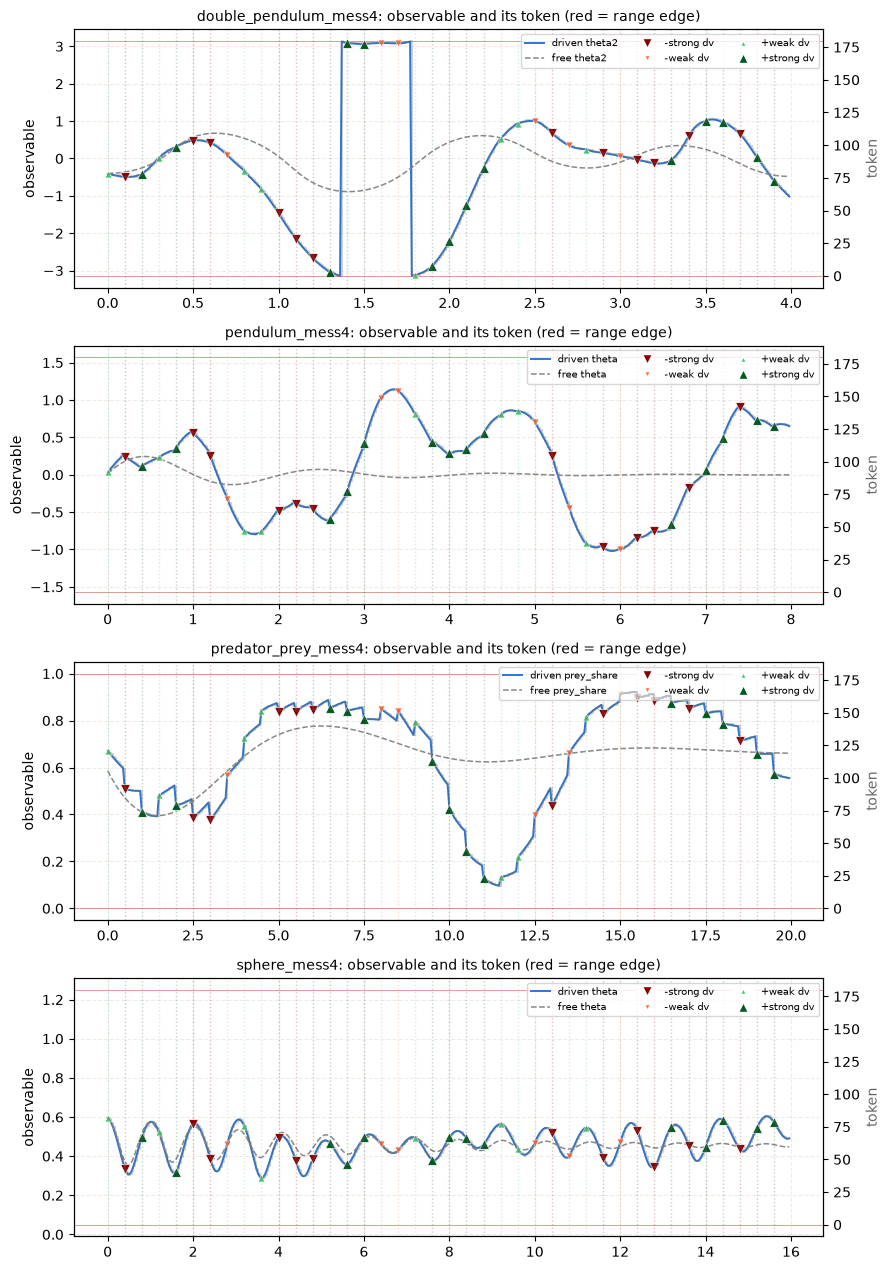

In [4]:
PANEL = "observable"   # any of V.PANELS
M_TICKS = 40
SEED = 0

traces = {name: V.trace(make_process(name, m=M_TICKS), seed=SEED)
          for name in sorted(MESSK_CONFIGS)}
fig = V.compare(traces, panel=PANEL)
plt.show()

## 4. The stability table

Every system at its committed defaults, scored by the same four numbers. This is the
row to re-run after changing any default in `physics/systems/` or
`physics/messk_configs.py`.

In [5]:
import pandas as pd

rows = []
for name, tr in traces.items():
    s = V.stability(tr)
    rows.append({
        "system": name,
        "lyapunov": round(s["lyapunov"], 3),
        "clipped %": round(100 * s["clipped"], 2),
        "bins used": f"{s['used_bins']}/{s['n_obs']}",
        "gap mean": round(s["gap_free_mean"], 3),
        "energy drift %": round(100 * s["energy_drift_free"], 1),
        "stable": s["stable"],
        "why not": "; ".join(s["reasons"]),
    })
pd.DataFrame(rows).set_index("system")

,lyapunov,clipped %,bins used,gap mean,energy drift %,stable,why not
system,,,,,,,
double_pendulum_mess4,0.976,0.0,109/181,5.335,-32.6,False,diverges from its own twin (lambda=+0.98/s)
pendulum_mess4,-0.563,0.0,121/181,1.506,-5.4,True,
predator_prey_mess4,-0.234,0.0,123/181,0.846,1.1,True,
sphere_mess4,0.096,0.0,48/181,0.648,-4.0,False,diverges from its own twin (lambda=+0.10/s)


## 5. One letter's causal effect

Replay one sequence with every possible letter at a single tick. The trajectories
agree exactly up to that tick and differ afterwards only because of that one impulse,
so the spread below is the whole of what a model could ever infer about that letter.

This is the panel that says whether the four actions are *distinguishable*. If the
four curves collapse onto each other the letters are unidentifiable from the tokens,
and no amount of training fixes that.

mean pairwise token separation after the branch: 19.8 bins


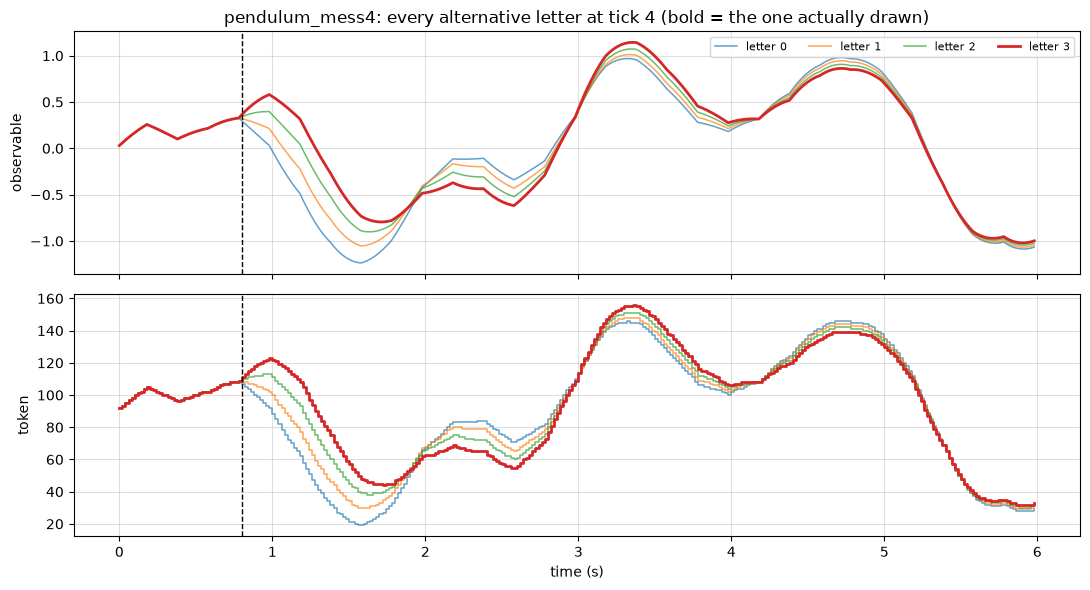

In [6]:
SYSTEM = "pendulum_mess4"
TICK = 4

proc = make_process(SYSTEM, m=30)
letters = proc.chain.sample(np.random.default_rng(0), 1, proc.m)[1][0]
variants = np.tile(letters, (proc.chain.n_states, 1))
variants[:, TICK] = np.arange(proc.chain.n_states)
out = proc.rollout(variants)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
t = np.arange(proc.seq_len) * proc.dt
for l in range(proc.chain.n_states):
    style = dict(lw=2.0, alpha=1.0) if l == letters[TICK] else dict(lw=1.1, alpha=0.7)
    axes[0].plot(t, out["observable"][l, :, 0], label=f"letter {l}", **style)
    axes[1].step(t, out["tokens"][l], where="post", label=f"letter {l}", **style)
axes[0].axvline(TICK * proc.n_steps * proc.dt, color="k", ls="--", lw=1)
axes[1].axvline(TICK * proc.n_steps * proc.dt, color="k", ls="--", lw=1)
axes[0].set_ylabel("observable"); axes[1].set_ylabel("token")
axes[1].set_xlabel("time (s)")
axes[0].set_title(f"{SYSTEM}: every alternative letter at tick {TICK} "
                  f"(bold = the one actually drawn)")
axes[0].legend(fontsize=8, ncol=4)
branch = TICK * proc.n_steps
tok = out["tokens"][:, branch:]
sep = np.abs(tok[:, None, :] - tok[None, :, :]).max(-1).mean()
print(f"mean pairwise token separation after the branch: {sep:.1f} bins")
plt.tight_layout(); plt.show()

## 6. Steady-State Energy Balance: Optimal Viscous Damping ($\\gamma^*$)

Computes the exact damping parameter $\\gamma^*$ where the average energy dissipated by viscous friction ($\\frac{dE}{dt} = -\\gamma \\omega^2$) exactly balances the average energy injected by the momentum perturbation kicks:

$$\\langle \\Delta E_{\\text{injected}} \\rangle = \\langle \\Delta E_{\\text{dissipated}} \\rangle$$

Use the sliders below to adjust $m$ (total ticks), $n$ (integration steps per tick), $dt$, $\\delta v$ (kick scale), $\\text{stay}$, and $\\alpha$ to find the optimal $\\gamma^*$ and visualize steady-state energy equilibrium.


In [ ]:
display(optimal_gamma_ui("pendulum_mess4"))
